# Model Evaluation Dashboard

Use this notebook to evaluate the trained safety-risk classifier, inspect key metrics, and generate plots such as the ROC curve and confusion matrix.


In [ ]:
import os
from pathlib import Path
import json

import numpy as np  # required for processing/reshaping confusion matrix and numeric types
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    brier_score_loss,
 )
import matplotlib.pyplot as plt
import seaborn as sns

# If you need to install missing packages in this environment, run:
# pip install matplotlib seaborn


In [3]:
# Update these paths as needed
# You can set CSV_PATH environment variable or modify the default below
CSV_PATH = os.getenv("CSV_PATH", r"C:\Users\user\Desktop\synthetic_up_locational_risk_data_fixed.csv")

# Resolve model path - try multiple locations
# The notebook is in backend/, so models are in backend/models/
NOTEBOOK_DIR = Path.cwd()

# Try to find models directory
model_paths_to_try = [
    NOTEBOOK_DIR / "backend" / "models" / "model_fixed.pkl",  # From project root
    NOTEBOOK_DIR / "models" / "model_fixed.pkl",  # From backend directory  
    Path("backend/models/model_fixed.pkl").resolve(),  # Relative path
    Path("models/model_fixed.pkl").resolve(),  # Alternative relative
]

# Find first existing model file
default_model = None
for model_path in model_paths_to_try:
    if model_path.exists():
        default_model = model_path
        break

# If model_fixed.pkl not found, try model.pkl
if default_model is None:
    alt_paths = [
        NOTEBOOK_DIR / "backend" / "models" / "model.pkl",
        NOTEBOOK_DIR / "models" / "model.pkl",
        Path("backend/models/model.pkl").resolve(),
        Path("models/model.pkl").resolve(),
    ]
    for alt_path in alt_paths:
        if alt_path.exists():
            default_model = alt_path
            print(f"Note: model_fixed.pkl not found, using model.pkl instead")
            break

# Use environment variable if set, otherwise use found default
if os.getenv("MODEL_PATH"):
    MODEL_PATH = Path(os.getenv("MODEL_PATH")).resolve()
else:
    MODEL_PATH = default_model.resolve() if default_model else None

# If still no model found, set a default path for user to update
if MODEL_PATH is None or not MODEL_PATH.exists():
    MODEL_PATH = Path("backend/models/model_fixed.pkl").resolve()

OUTPUT_JSON = Path("backend/metrics.json").resolve()

print(f"CSV_PATH: {CSV_PATH}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"OUTPUT_JSON: {OUTPUT_JSON}")

# Check if files exist
if not Path(CSV_PATH).exists():
    print(f"\n⚠️  WARNING: CSV file not found at {CSV_PATH}")
    print("   Please update CSV_PATH above or set the CSV_PATH environment variable.")
    print("   Example: CSV_PATH = r'C:\\path\\to\\your\\dataset.csv'")
else:
    print(f"✓ CSV file found")

# Check model file with better error handling
if not MODEL_PATH.exists():
    print(f"\n⚠️  WARNING: Model file not found at {MODEL_PATH}")
    # Try to find models directory
    models_dir = MODEL_PATH.parent
    print(f"   Checking available models in {models_dir}...")
    if models_dir.exists():
        available_models = list(models_dir.glob("*.pkl"))
        if available_models:
            print(f"   Available model files:")
            for model_file in available_models:
                print(f"     - {model_file.name}")
            print(f"\n   Try updating MODEL_PATH in this cell, for example:")
            print(f"   MODEL_PATH = Path(r'{available_models[0]}').resolve()")
        else:
            print(f"   No .pkl model files found in {models_dir}")
    else:
        # Try alternative locations
        alt_dirs = [
            Path("backend/models"),
            Path("models"),
            NOTEBOOK_DIR / "backend" / "models",
            NOTEBOOK_DIR / "models",
        ]
        for alt_dir in alt_dirs:
            if alt_dir.exists():
                available_models = list(alt_dir.glob("*.pkl"))
                if available_models:
                    print(f"   Found models in: {alt_dir}")
                    print(f"   Available model files:")
                    for model_file in available_models:
                        print(f"     - {model_file}")
                    print(f"\n   Update MODEL_PATH to: MODEL_PATH = Path(r'{available_models[0]}').resolve()")
                    break
else:
    print(f"✓ Model file found: {MODEL_PATH.name}")


CSV_PATH: C:\Users\user\Desktop\synthetic_up_locational_risk_data_fixed.csv
MODEL_PATH: C:\Users\user\Documents\Women_Safety_Project\backend\models\model_fixed.pkl
OUTPUT_JSON: C:\Users\user\Documents\Women_Safety_Project\backend\backend\metrics.json
✓ CSV file found
✓ Model file found: model_fixed.pkl


In [4]:
def load_dataset(csv_path: str):
    """Load and validate the dataset. Handles both fixed (no Is_Night_Risk) and original datasets."""
    # Required columns (Is_Night_Risk is optional - removed in fixed dataset)
    required_base = [
        "District",
        "Latitude",
        "Longitude",
        "Hour",
        "Day_of_Week",
        "Is_High_Density_Area",
        "Target_Risk_Y",
    ]

    if not Path(csv_path).exists():
        raise FileNotFoundError(f"CSV file not found: {csv_path}")
    
    df = pd.read_csv(csv_path)
    
    # Check for base required columns
    missing = [col for col in required_base if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    print(f"Dataset shape: {df.shape}")
    print(f"Available columns: {list(df.columns)}")
    print(f"\nTarget distribution:\n{df['Target_Risk_Y'].value_counts()}")
    
    # Determine feature columns based on what's available
    # Fixed dataset: District, Latitude, Longitude, Hour, Day_of_Week, Is_High_Density_Area
    # Original dataset: includes Is_Night_Risk
    feature_cols = required_base[:-1]  # All except Target_Risk_Y
    
    # Add Is_Night_Risk only if it exists (for original dataset compatibility)
    if "Is_Night_Risk" in df.columns:
        feature_cols.append("Is_Night_Risk")
        print(f"\n⚠️  Note: Dataset includes 'Is_Night_Risk' (may cause data leakage)")
        print(f"   Consider using the fixed dataset without this column.")
    else:
        print(f"\n✓ Using fixed dataset (without Is_Night_Risk)")

    X = df[feature_cols].copy()
    y = df["Target_Risk_Y"].astype(int)
    return X, y, feature_cols


# Load the dataset
X, y, feature_columns = load_dataset(CSV_PATH)
print(f"\n✓ Loaded dataset with {len(X)} rows and {len(feature_columns)} features.")


Dataset shape: (1680, 7)
Available columns: ['District', 'Latitude', 'Longitude', 'Hour', 'Day_of_Week', 'Is_High_Density_Area', 'Target_Risk_Y']

Target distribution:
Target_Risk_Y
0    1302
1     378
Name: count, dtype: int64

✓ Using fixed dataset (without Is_Night_Risk)

✓ Loaded dataset with 1680 rows and 6 features.

Target distribution:
Target_Risk_Y
0    1302
1     378
Name: count, dtype: int64

✓ Using fixed dataset (without Is_Night_Risk)

✓ Loaded dataset with 1680 rows and 6 features.


In [5]:
# Split data into train and test sets
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 1344, Test size: 336


In [6]:
# Load the trained model (robust, clear errors if missing)
if MODEL_PATH is None:
    raise FileNotFoundError("MODEL_PATH is not set. Please set MODEL_PATH in the previous cell.")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH} -- please update MODEL_PATH in cell 2 and ensure model file exists.")

try:
    model = joblib.load(MODEL_PATH)
    print(f"✓ Loaded model: {type(model).__name__}")
    print(f"Model file: {MODEL_PATH.resolve()}")
except Exception as e:
    raise RuntimeError(f"Failed to load model from {MODEL_PATH}: {e}")


✓ Loaded model: Pipeline
Model file: C:\Users\user\Documents\Women_Safety_Project\backend\models\model_fixed.pkl


In [7]:
# Make predictions (ensure features match)
expected_features = feature_columns
missing = [f for f in expected_features if f not in X_test.columns]
if missing:
    raise ValueError(f"Missing expected feature columns in X_test: {missing}")

# Run predict using the same feature ordering the model expects
X_model = X_test[expected_features].copy()
y_pred = model.predict(X_model)

# Try probabilities if available
y_proba = None
if hasattr(model, "predict_proba"):
    try:
        y_proba = model.predict_proba(X_model)[:, 1]
        print("✓ Probability predictions available")
    except Exception as exc:
        print(f"⚠️ Warning: could not compute probabilities: {exc}")
else:
    print("⚠️ Model does not support predict_proba()")

# Calculate metrics
metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred, zero_division=0)),
    "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    "classification_report": classification_report(y_test, y_pred, digits=3, output_dict=True),
}
if y_proba is not None:
    metrics["roc_auc"] = float(roc_auc_score(y_test, y_proba))
    metrics["brier_score"] = float(brier_score_loss(y_test, y_proba))

print("✓ Metrics calculated")

✓ Probability predictions available
✓ Metrics calculated


In [8]:
# Display summary metrics
summary_metrics = {
    key: value
    for key, value in metrics.items()
    if key in {"accuracy", "precision", "recall", "f1", "roc_auc", "brier_score"}
}

print("Summary Metrics:")
pd.DataFrame([summary_metrics])


Summary Metrics:


,accuracy,precision,recall,f1,roc_auc,brier_score
0,1.0,1.0,1.0,1.0,1.0,0.00087


In [9]:
# Detailed classification report
print("Detailed Classification Report:")
classification_df = pd.DataFrame(metrics["classification_report"]).T
classification_df


Detailed Classification Report:


,precision,recall,f1-score,support
0,1.0,1.0,1.0,260.0
1,1.0,1.0,1.0,76.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,336.0
weighted avg,1.0,1.0,1.0,336.0


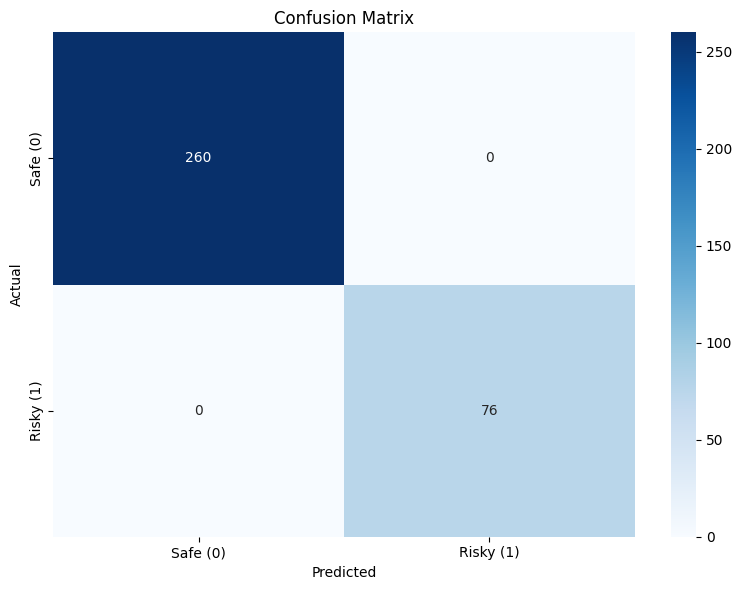

In [ ]:
# Confusion Matrix Visualization (robust and informative)
cm = metrics.get("confusion_matrix")
if cm is None:
    raise KeyError("metrics does not contain 'confusion_matrix'; make sure metrics were computed before plotting")

# Convert to numpy array and ensure it's 2x2 (or proper square) for plotting
cm_arr = np.asarray(cm)
if cm_arr.ndim == 1 and cm_arr.size == 4:
    cm_arr = cm_arr.reshape((2, 2))
elif cm_arr.ndim != 2 or cm_arr.shape[0] != cm_arr.shape[1] or cm_arr.size == 0:
    # Fallback: try to coerce into a square matrix if possible, otherwise raise a helpful error
    try:
        cm_arr = cm_arr.reshape(int(np.sqrt(cm_arr.size)), -1)
    except Exception as e:
        raise ValueError(f"Unable to interpret confusion matrix shape: {cm_arr.shape} (error: {e})")

# Convert values to integers for display (some inputs may be floats)
cm_display = cm_arr.astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_display, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=["Predicted: Safe (0)", "Predicted: Risky (1)"],
            yticklabels=["Actual: Safe (0)", "Actual: Risky (1)"])
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

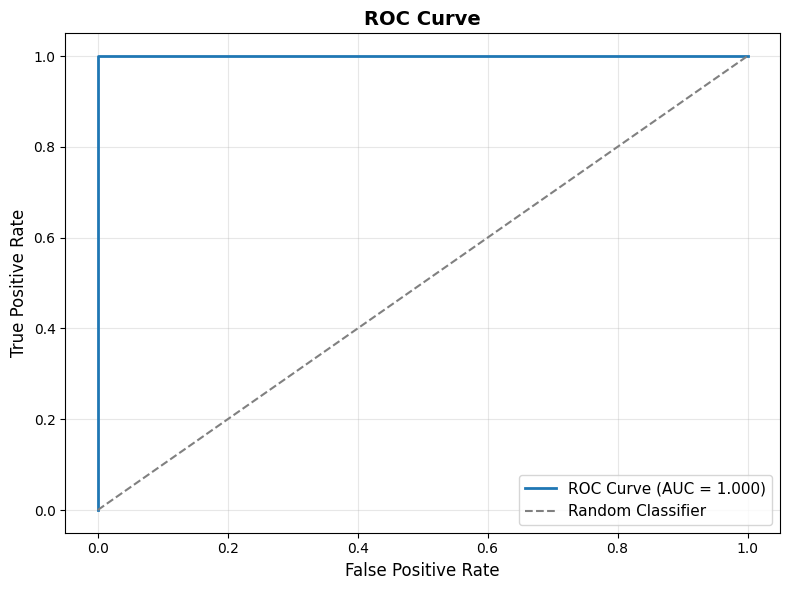

In [15]:
# ROC Curve Visualization
if y_proba is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = metrics.get('roc_auc', float('nan'))
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("ROC Curve", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ROC curve unavailable: model does not expose predict_proba().")


In [18]:
# Save metrics to JSON file
OUTPUT_JSON.parent.mkdir(parents=True, exist_ok=True)

def make_json_serializable(obj):
    """Recursively convert numpy types/arrays and other non-serializable values
    into native Python types so json.dump won't crash.
    """
    # Import numpy locally so this function works even if 'np' isn't defined globally
    try:
        import numpy as _np
    except Exception:
        _np = None
    # numpy arrays -> lists, numpy scalars -> native types
    if _np is not None and isinstance(obj, getattr(_np, 'ndarray', ())):
        return obj.tolist()
    if _np is not None and isinstance(obj, (getattr(_np, 'integer', ()), getattr(_np, 'int_', ()), getattr(_np, 'intc', ()), getattr(_np, 'intp', ()), getattr(_np, 'int8', ()), getattr(_np, 'int16', ()), getattr(_np, 'int32', ()), getattr(_np, 'int64', ()))):
        return int(obj)
    if _np is not None and isinstance(obj, (getattr(_np, 'floating', ()), getattr(_np, 'float_', ()), getattr(_np, 'float16', ()), getattr(_np, 'float32', ()), getattr(_np, 'float64', ()))):
        return float(obj)
    if _np is not None and isinstance(obj, (getattr(_np, 'bool_', ()),)):
        return bool(obj)

    # lists -> recurse into items
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]

    # dicts -> recurse into values
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}

    # pandas objects -> convert to native types where possible
    try:
        import pandas as _pd
        if isinstance(obj, (_pd.Series, _pd.DataFrame)):
            try:
                return obj.to_dict()
            except Exception:
                return obj.values.tolist()
    except Exception:
        pass

    # fall back - if already JSON serializable this will succeed, otherwise convert to str
    try:
        json.dumps(obj)
        return obj
    except Exception:
        return str(obj)

def serialize_metrics(metrics_dict):
    """Convert the full metrics dictionary into a JSON-friendly structure."""
    return make_json_serializable(metrics_dict)

with open(OUTPUT_JSON, "w", encoding="utf-8") as fp:
    json.dump(serialize_metrics(metrics), fp, indent=2)

print(f"✓ Saved metrics to {OUTPUT_JSON.resolve()}")

✓ Saved metrics to C:\Users\user\Documents\Women_Safety_Project\backend\backend\metrics.json
